# Accra Property Sales — Predictive Analytics
## Group Coursework
### City: Accra, Ghana (Developing Economy)¶


In [1]:
#Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# DATA UNDERSTANDING

In [2]:
#Loading the dataset
df=pd.read_csv('ACCRA DATASET _new.csv')

In [3]:
df.head()

,Date,price,category,bedrooms,bathrooms,floor_area,condition,parking_space,is_furnished,lat,lng,locality,region
0,06/02/2023,9196,Flats,2,2,145,Used,False,Semi-Furnished,5.635828,-0.161359,East Legon,Greater Accra
1,22/05/2023,7500,Flats,2,2,100,Used,False,Unfurnished,5.614123,-0.195647,Dzorwulu,Greater Accra
2,14/05/2023,11200,Detached,4,5,100,New,False,Semi-Furnished,5.680213,-0.137248,Ashaley Botwe,Greater Accra
3,21/04/2025,2500,Detached,3,3,17,Used,False,Semi-Furnished,5.583166,-0.104608,Teshie,Greater Accra
4,09/05/2024,9146,Detached,3,3,160,Used,False,Semi-Furnished,5.637614,-0.126606,Spintex,Greater Accra


In [4]:
df.shape

(4320, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           4320 non-null   object 
 1   price          4320 non-null   int64  
 2   category       4320 non-null   object 
 3   bedrooms       4320 non-null   int64  
 4   bathrooms      4320 non-null   int64  
 5   floor_area     4320 non-null   int64  
 6   condition      4320 non-null   object 
 7   parking_space  4320 non-null   bool   
 8   is_furnished   4320 non-null   object 
 9   lat            4320 non-null   float64
 10  lng            4320 non-null   float64
 11  locality       4320 non-null   object 
 12  region         4320 non-null   object 
dtypes: bool(1), float64(2), int64(4), object(6)
memory usage: 409.3+ KB


In [6]:
df.describe()

,price,bedrooms,bathrooms,floor_area,lat,lng
count,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000
mean,13039.137037,2.478472,2.632407,467.298380,5.749976,-0.280327
std,13265.856002,1.287552,1.408822,853.287636,0.498949,0.378747
min,416.000000,1.000000,1.000000,10.000000,4.849041,-2.361620
25%,2500.000000,2.000000,2.000000,100.000000,5.595846,-0.210399
50%,8000.000000,2.000000,2.000000,145.000000,5.635828,-0.161359
75%,19200.000000,3.000000,3.000000,541.250000,5.680213,-0.137248
max,59500.000000,20.000000,20.000000,5000.000000,9.410999,0.563609


In [7]:
#Checking for missing values
df.isna().sum()

Date             0
price            0
category         0
bedrooms         0
bathrooms        0
floor_area       0
condition        0
parking_space    0
is_furnished     0
lat              0
lng              0
locality         0
region           0
dtype: int64

In [8]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
df = df[df["region"] == "Greater Accra"].copy()
print(f"After filtering to Greater Accra: {df.shape}")

After filtering to Greater Accra: (3917, 13)


In [10]:
#Clean and parse the Date column
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

In [11]:
# Encode categorical fields
# Ordinal encode furnishing level (natural order: Unfurnished < Semi < Furnished)
furnish_map = {"Unfurnished": 0, "Semi-Furnished": 1, "Furnished": 2}
df["furnished_level"] = df["is_furnished"].map(furnish_map)

In [12]:
# Ordinal encode condition (natural order: Used < Renovated < New)
condition_map = {"Used": 0, "Renovated": 1, "New": 2}
df["condition_level"] = df["condition"].map(condition_map)

In [13]:
# parking_space is already boolean -> convert to 0/1
df["parking_space"] = df["parking_space"].astype(int)

In [14]:
# Group rare localities (<30 listings) into "Other" before one-hot encoding
locality_counts = df["locality"].value_counts()
rare_localities = locality_counts[locality_counts < 30].index
df["locality_grouped"] = df["locality"].where(~df["locality"].isin(rare_localities), "Other")
print(f"\nLocalities kept individually: {df['locality_grouped'].nunique() - 1}")
print(f"Listings grouped into 'Other': {(df['locality_grouped'] == 'Other').sum()}")


Localities kept individually: 24
Listings grouped into 'Other': 468


In [15]:
# One-hot encode category and grouped locality
df = pd.get_dummies(df, columns=["category", "locality_grouped"], prefix=["cat", "loc"])

In [16]:
#Outlier detection and handling (IQR method) on price and floor_area
def cap_outliers_iqr(series, factor=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - factor * iqr, q3 + factor * iqr
    return series.clip(lower=lower, upper=upper), lower, upper

before_price_max = df["price"].max()
df["price_capped"], p_low, p_high = cap_outliers_iqr(df["price"])
print(f"\nPrice IQR bounds: [{p_low:.0f}, {p_high:.0f}] (was max {before_price_max})")

before_area_max = df["floor_area"].max()
df["floor_area_capped"], a_low, a_high = cap_outliers_iqr(df["floor_area"])
print(f"Floor area IQR bounds: [{a_low:.0f}, {a_high:.0f}] (was max {before_area_max})")



Price IQR bounds: [-22500, 45500] (was max 59500)
Floor area IQR bounds: [-620, 1300] (was max 5000)


In [17]:
#Feature engineering
# Price per square metre (using capped values to avoid division blow-ups)
df["price_per_sqm"] = df["price_capped"] / df["floor_area_capped"]

# Bedroom-to-bathroom ratio
df["bed_bath_ratio"] = df["bedrooms"] / df["bathrooms"].replace(0, np.nan)

In [18]:
# Distance from Accra CBD (approx coordinates of central Accra: 5.5560, -0.1969)
CBD_LAT, CBD_LNG = 5.5560, -0.1969
df["distance_from_cbd_km"] = np.sqrt(
    (df["lat"] - CBD_LAT) ** 2 + (df["lng"] - CBD_LNG) ** 2
) * 111  # rough degrees-to-km conversion

In [19]:
# Extract time-based features useful for regression too
df["sale_year"] = df["Date"].dt.year
df["sale_month"] = df["Date"].dt.month

In [20]:
#Save the cleaned, regression-ready dataset
regression_cols = [c for c in df.columns if c not in ["price", "floor_area", "condition", "is_furnished", "locality"]]
df_regression = df[regression_cols].copy()
df_regression.to_csv("accra_cleaned_regression.csv", index=False)
print(f"\nSaved regression-ready dataset: accra_cleaned_regression.csv ({df_regression.shape[0]} rows, {df_regression.shape[1]} cols)")


Saved regression-ready dataset: accra_cleaned_regression.csv (3917 rows, 47 cols)


In [21]:
#Loading the cleaned dataset
df1=pd.read_csv('accra_cleaned_regression.csv')

In [22]:
df1.head()

,Date,bedrooms,bathrooms,parking_space,lat,lng,region,furnished_level,condition_level,cat_Detached,...,loc_Teshie,loc_Weija,loc_West Legon,price_capped,floor_area_capped,price_per_sqm,bed_bath_ratio,distance_from_cbd_km,sale_year,sale_month
0,2023-02-06,2,2,0,5.635828,-0.161359,Greater Accra,1,0,False,...,False,False,False,9196,145,63.420690,1.0,9.699440,2023,2
1,2023-05-22,2,2,0,5.614123,-0.195647,Greater Accra,0,0,False,...,False,False,False,7500,100,75.000000,1.0,6.453174,2023,5
2,2023-05-14,4,5,0,5.680213,-0.137248,Greater Accra,1,2,True,...,False,False,False,11200,100,112.000000,0.8,15.295147,2023,5
3,2025-04-21,3,3,0,5.583166,-0.104608,Greater Accra,1,0,True,...,True,False,False,2500,17,147.058824,1.0,10.678982,2025,4
4,2024-05-09,3,3,0,5.637614,-0.126606,Greater Accra,1,0,True,...,False,False,False,9146,160,57.162500,1.0,11.956081,2024,5


In [23]:
df1.shape

(3917, 47)

In [24]:
df1["Date"] = pd.to_datetime(df1["Date"])

# DATA VISUALIZATION

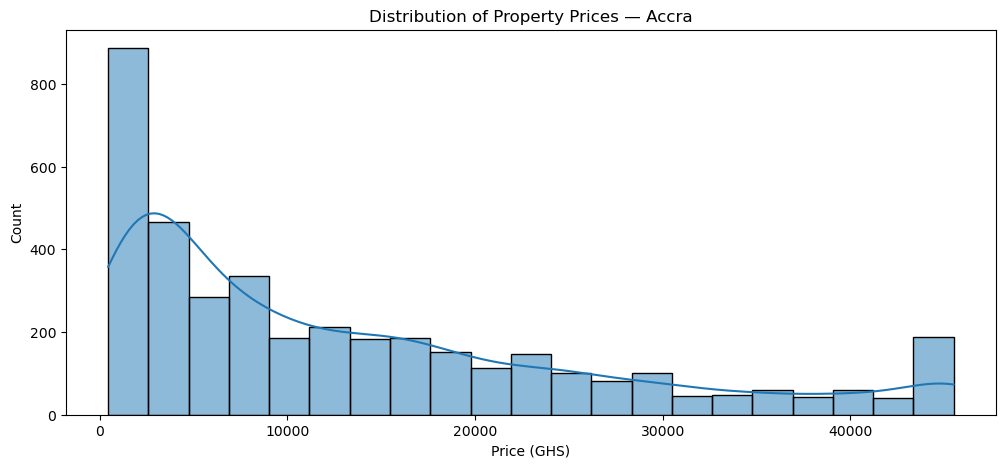

In [70]:
plt.figure(figsize=(12,5))
sns.histplot(df["price_capped"], kde=True)
plt.title("Distribution of Property Prices — Accra")
plt.xlabel("Price (GHS)")
plt.show()

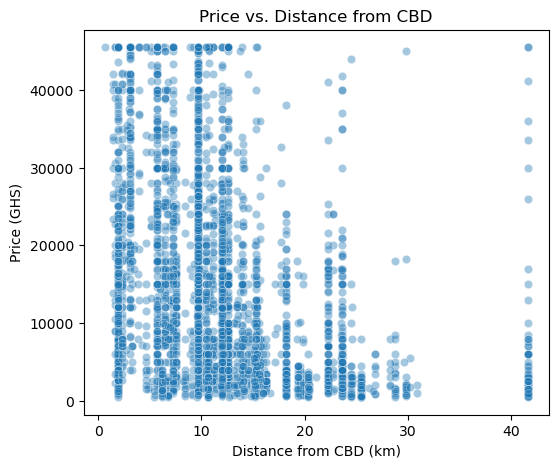

In [71]:
#Checking for relationship between distance and price
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="distance_from_cbd_km", y="price_capped", alpha=0.4)
plt.title("Price vs. Distance from CBD")
plt.xlabel("Distance from CBD (km)")
plt.ylabel("Price (GHS)")
plt.show()

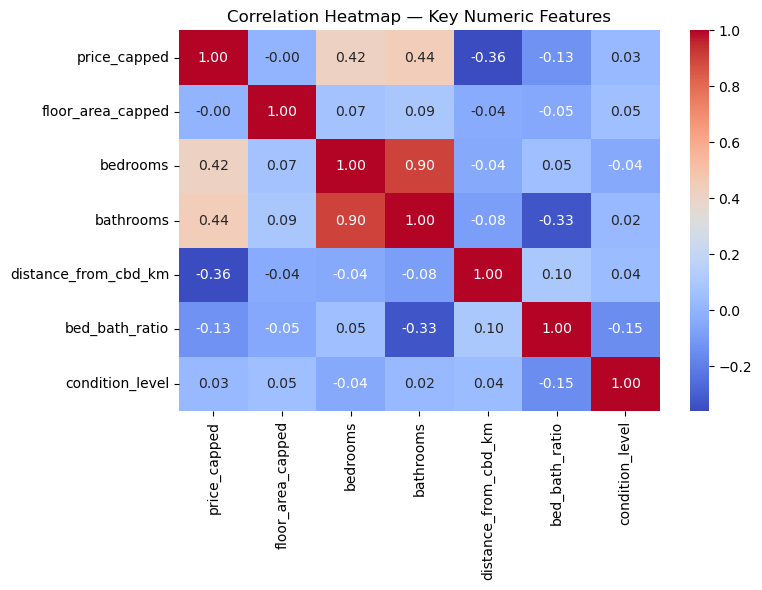

In [72]:
#Checking for correlatin between the features
key_features = ["price_capped", "floor_area_capped", "bedrooms", "bathrooms",
                 "distance_from_cbd_km", "bed_bath_ratio", "condition_level"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[key_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap — Key Numeric Features")
plt.tight_layout()
plt.show()

In [25]:
drop_cols=["region", "price_per_sqm", "Date", "price_capped"]

# Splitting the Data

In [26]:
#Defining the target
x=df1.drop(columns=drop_cols)
y=df1['price_capped']

In [27]:
#Splitting the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Feature Scaling

In [28]:
# Scaling numeric features
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)  

# Building the Model

In [29]:
model=LinearRegression()

In [30]:
model.fit(x_train_sc,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
#Making predictions
y_pred=model.predict(x_test_sc)
print(y_pred[:10])

[20955.39172708 26611.0502805  11256.17757449  9049.74172586
 16204.86949339 33081.38033511 19146.06259895 15946.42436585
 13333.72647985 19358.56847259]


In [32]:
#Model interceot
model.intercept_

np.float64(13584.233003511015)

In [33]:
#Model coefficient
model.coef_

array([ 2851.06337323,  1719.81851064,  -381.69848723,   441.03643528,
        1309.79997388,  4408.4365633 ,   639.29908118,   175.85691414,
        -106.6798863 ,  -602.32719038,   367.97334574,  -275.35776104,
        1203.60759846,  -700.78906636,  -539.61630312,  -562.66565363,
        -955.68081154,   352.11368234,  1565.35325337,  -586.73926779,
        -549.16765537,  2389.21371434,  -478.34479808,   533.09869516,
        1264.9370454 ,  -434.28771457,  -423.69667803,  -177.2312451 ,
         508.98986444,    47.10889085,   355.36149004,  -211.25198926,
        -370.03407429,  -667.26674905,  -940.55078061,  -397.5655296 ,
        -384.36519161,   -28.99304236,   181.75413632,   118.15012803,
       -2498.48893647,   -33.52733284,    57.66628716])

In [34]:
#Checking for errors
residuals=y_test-y_pred
residuals

270      1544.608273
2015    -8611.050280
802     -7756.177574
2899    -4049.741726
2005    -7204.869493
            ...     
2042    -2979.811526
3784    -2615.437071
1270     5320.635697
1132    10769.384079
578     -1860.987678
Name: price_capped, Length: 784, dtype: float64

In [35]:
results=pd.DataFrame({'Actual':y_test,
                      'Predicted':y_pred})
results

,Actual,Predicted
270,22500,20955.391727
2015,18000,26611.050280
802,3500,11256.177574
2899,5000,9049.741726
2005,9000,16204.869493
...,...,...
2042,18000,20979.811526
3784,1500,4115.437071
1270,14400,9079.364303
1132,15000,4230.615921


In [36]:
results['Residual']=residuals
results.head()

,Actual,Predicted,Residual
270,22500,20955.391727,1544.608273
2015,18000,26611.050280,-8611.050280
802,3500,11256.177574,-7756.177574
2899,5000,9049.741726,-4049.741726
2005,9000,16204.869493,-7204.869493


In [37]:
#Checking for r2 score
r2=r2_score(y_test,y_pred)
r2

0.6226735418577547

In [60]:
mae=mean_absolute_error(y_test,y_pred)
mae

6028.784487315781

# Lasso Regression

In [73]:
from sklearn.linear_model import LassoCV

alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
lasso_cv = LassoCV(alphas=alphas, cv=5)
lasso_cv.fit(x_train_sc, y_train)            #Fitting the data

print("Best alpha:", lasso_cv.alpha_)
y_pred_ridge = lasso_cv.predict(x_test_sc)
r2_score(y_test, y_pred_ridge)

Best alpha: 50.0


0.622529388750372

# TIME SERIES
## 3 month SMA

In [46]:
# --- Aggregate to monthly average price across Greater Accra ---
monthly = (
    df.set_index("Date")
      .resample("MS")["price_capped"]
      .mean()
      .rename("avg_price")
      .to_frame()
)

print(monthly)

               avg_price
Date                    
2023-01-01  12765.063830
2023-02-01  14351.088496
2023-03-01  12092.353846
2023-04-01  13094.645161
2023-05-01  15490.594828
2023-06-01  14469.096154
2023-07-01  12940.731034
2023-08-01  12602.944954
2023-09-01  11886.560748
2023-10-01  13728.918919
2023-11-01  16084.938776
2023-12-01  15094.411765
2024-01-01  13056.500000
2024-02-01  12581.062500
2024-03-01  12954.870370
2024-04-01  12595.048077
2024-05-01  14188.530435
2024-06-01  13509.519608
2024-07-01  13564.252336
2024-08-01  12263.204082
2024-09-01  14635.473214
2024-10-01  11968.793651
2024-11-01  14457.394231
2024-12-01  15430.128440
2025-01-01  13778.514563
2025-02-01  13597.344828
2025-03-01  12156.560748
2025-04-01  12209.938596
2025-05-01  14276.975806
2025-06-01  14131.803419
2025-07-01  14696.596639
2025-08-01  13773.214953
2025-09-01  14717.377551
2025-10-01  14368.297030
2025-11-01  13529.252874
2025-12-01  12283.981308


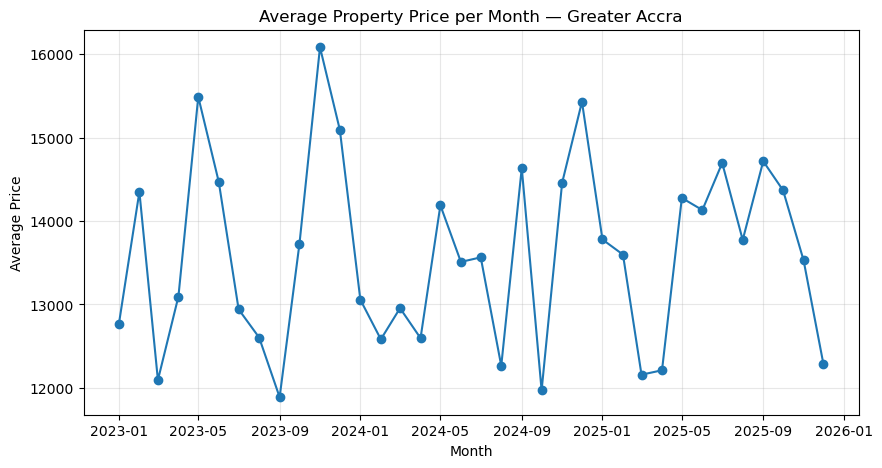

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly["avg_price"], marker="o")
plt.title("Average Property Price per Month — Greater Accra")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.grid(alpha=0.3)
plt.show()

In [48]:
#Simple moving average forecast 
window = 3  # 3-month SMA 

monthly["SMA"] = monthly["avg_price"].rolling(window=window).mean()

train_size = int(len(monthly) * 0.8)
train, test = monthly.iloc[:train_size], monthly.iloc[train_size:]

In [49]:
# Recursive SMA forecast over the test period
history = list(train["avg_price"])
forecast = []
for _ in range(len(test)):
    next_val = np.mean(history[-window:])
    forecast.append(next_val)
    history.append(next_val)

In [50]:
test = test.copy()
test["forecast"] = forecast

In [55]:
#Checking for errors
mae = mean_absolute_error(test["avg_price"], test["forecast"])
mse = mean_squared_error(test["avg_price"], test["forecast"])
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test["avg_price"] - test["forecast"]) / test["avg_price"])) * 100

print(f"MAE:  {mae:,.0f}")
print(f"MSE: {mse:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"MAPE: {mape:.2f}%")

MAE:  1,564
MSE: 2,898,190
RMSE: 1,702
MAPE: 10.95%


## ARIMA

In [56]:
#Ho: It is non stationary
#H1: It is stationary
from statsmodels.tsa.stattools import adfuller
test_result=adfuller(monthly['avg_price'])

In [57]:
def adfuller_test(price):
    result=adfuller(price)
    labels=['ADF Test Statistic', 'p-value', '#Lags Used', 'Number of Observation Used']
    for value, label in zip(result, labels):
        print(label+':'+str(value))
    if result[1]<=0.05:
        print('strong evidence against the null hypothesis(Ho), reject the null hypothesi. Data has no unit root and is stationary')
    else:
        print('weak evidence against the null hypothesis, time series has a unit root, indicating it is non stationary')
adfuller_test(monthly['avg_price'])

ADF Test Statistic:-5.174879823478152
p-value:9.891912017655479e-06
#Lags Used:2
Number of Observation Used:33
strong evidence against the null hypothesis(Ho), reject the null hypothesi. Data has no unit root and is stationary


In [58]:
monthly.head()

,avg_price,SMA
Date,,
2023-01-01,12765.063830,NaN
2023-02-01,14351.088496,NaN
2023-03-01,12092.353846,13069.502057
2023-04-01,13094.645161,13179.362501
2023-05-01,15490.594828,13559.197945


In [59]:
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

In [63]:
clean_data=monthly['avg_price'].dropna()
auto_model=auto_arima(clean_data,
                      start_p=0, start_q=0,
                      max_p=5, max_q=5,
                      m=12,
                      seasonal=True,
                      d=None,
                      trace=True,
                      error_action='ignore',
                      duppress_warnings=True,
                      stepwise=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=612.885, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=610.105, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=612.816, Time=0.09 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=612.014, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=789.640, Time=0.01 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=612.101, Time=0.03 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=610.833, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=611.263, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=610.767, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=613.012, Time=0.03 sec

Best model:  ARIMA(0,0,0)(0,0,0)[12] intercept
Total fit time: 0.426 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   36
Model:                        SARIMAX   Log Likelihood       

In [64]:
#Check model performance
print('Model Summary')
print(auto_model.summary())

Model Summary
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   36
Model:                        SARIMAX   Log Likelihood                -303.053
Date:                Tue, 04 Aug 2026   AIC                            610.105
Time:                        16:29:10   BIC                            613.272
Sample:                    01-01-2023   HQIC                           611.211
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1.359e+04    187.436     72.518      0.000    1.32e+04     1.4e+04
sigma2      1.201e+06   3.79e+05      3.172      0.002    4.59e+05    1.94e+06
Ljung-Box (L1) (Q):                   

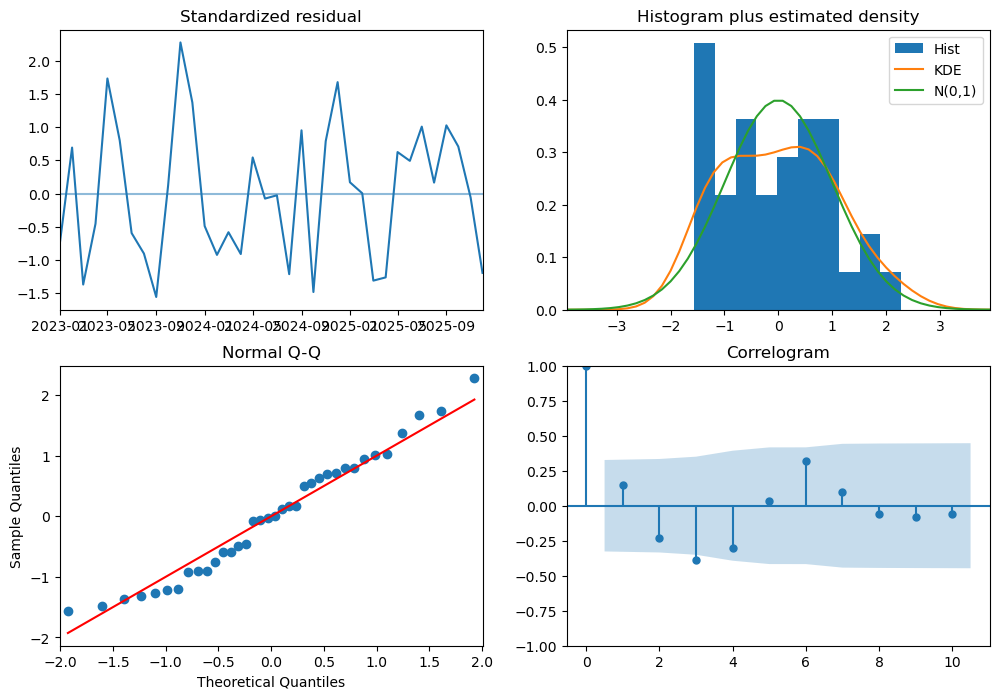

In [65]:
#Plot residuals
auto_model.plot_diagnostics(figsize=(12,8))
plt.show()

## Recommendations for Miss Akoto — ED Happiness Estates
### Focus Market: Accra, Ghana (Developing Economy)

Based on our predictive analysis of the Accra residential real estate market, the following five 
recommendations are offered to guide deployment of investment capital.

### 1. Enter the Accra market with a phased, moderate-risk capital allocation
Our regression model explains approximately 62% of the variance in Accra property prices 
(R² ≈ 0.62), indicating that price behavior in this market is reasonably — but not fully — 
predictable from observable property characteristics. This suggests Accra is a data-tractable 
market for planning purposes, but unmodeled factors (e.g., informal negotiation, title/legal 
status, off-market deals) still account for a meaningful share of price variation. We recommend 
an initial moderate tranche of capital rather than full deployment, pending further data 
refinement.

### 2. Concentrate development in high-value, high-demand localities
[Fill in once you have feature importance / coefficient output: e.g., "Regression results show 
that floor area, bedroom count, and proximity to the CBD are the strongest positive predictors 
of price, with properties in [East Legon / Cantonments / Airport Residential Area] commanding 
the highest premiums."] ED Happiness Estates should prioritize acquiring land in these corridors 
to maximize both rental yield and resale value.